In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os

# ── PATHS ──────────────────────────────────────────────────────
data_dir = "/projectnb/ds596/projects/Team_7/data/"
scrna_dir = os.path.join(data_dir, "mousescRNAseq")
visium_dir = os.path.join(data_dir, "mouseVisium")

# ── STEP 1: LOAD snRNA-seq ─────────────────────────────────────
scrna_samples = [
    "5705STDY8058280",
    "5705STDY8058281",
    "5705STDY8058282",
    "5705STDY8058283",
    "5705STDY8058284",
    "5705STDY8058285",
]

adatas = []
for sample in scrna_samples:
    path = os.path.join(scrna_dir, f"{sample}_filtered_feature_bc_matrix.h5")
    adata = sc.read_10x_h5(path)
    adata.var_names_make_unique()
    adata.obs["sample"] = sample
    # Make cell IDs match annotation file format: sampleID_barcode
    adata.obs_names = [f"{sample}_{bc}" for bc in adata.obs_names]
    adatas.append(adata)
    print(f"Loaded {sample}: {adata.shape}")

# Concatenate
adata_snrna = sc.concat(adatas)
print(f"\nCombined snRNA-seq: {adata_snrna.shape}")

# ── STEP 2: ATTACH CELL TYPE ANNOTATIONS ──────────────────────
cell_annot = pd.read_csv(
    os.path.join(scrna_dir, "cell_annotation.csv"),
    index_col="Cell ID"
)
print(f"\nAnnotation shape: {cell_annot.shape}")
print(f"Cell types (annotation_1): {cell_annot['annotation_1'].nunique()} unique")
print(cell_annot["annotation_1"].value_counts())

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/opt/conda/envs/cellpymc/lib/python3.7/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Loaded 5705STDY8058280: (8809, 31053)


Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Loaded 5705STDY8058281: (8913, 31053)


Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


...

Loaded 5705STDY8058283: (5751, 31053)


Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Loaded 5705STDY8058284: (3284, 31053)


Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Loaded 5705STDY8058285: (11439, 31053)

Combined snRNA-seq: (44429, 31053)

Annotation shape: (40532, 3)
Cell types (annotation_1): 59 unique
Oligo_2           10819
Ext_L56            1422
Inh_4              1389
Ext_L23            1244
Micro              1218
Ext_Thal_1         1197
OPC_1              1015
Ext_Pir             954
Ext_L25             922
Ext_Hpc_DG2         915
Ext_L5_1            893
Unk_1               864
Inh_2               839
Inh_3               818
Inh_Pvalb           804
Ext_Amy_2           797
Inh_Meis2_3         789
Ext_Thal_2          671
Ext_Hpc_CA1         671
Inh_Sst             640
Oligo_1             613
Inh_Meis2_2         602
Inh_1               573
Ext_L6              568
Ext_Hpc_DG1         554
Inh_Vip             545
Ext_Amy_1           519
Astro_AMY           498
Inh_6               467
Astro_HYPO          451
Astro_CTX           443
Ext_Unk_3           416
Astro_THAL_med      405
Inh_Meis2_1         363
Ext_L6B             356
Astro_THAL_lat    

In [2]:
# Sanity check before running — confirm cell ID format matches:

# Check first few obs_names from loaded data
print("Loaded cell IDs (first 3):")
print(adata_snrna.obs_names[:3].tolist())

# Check first few cell IDs from annotation file
print("\nAnnotation cell IDs (first 3):")
print(cell_annot.index[:3].tolist())

# These must match exactly — if they don't we fix the formatting

Loaded cell IDs (first 3):
['5705STDY8058280_AAACCCAAGGAAGTAG-1', '5705STDY8058280_AAACCCAAGGGCAGTT-1', '5705STDY8058280_AAACCCAAGGTTGTTC-1']

Annotation cell IDs (first 3):
['5705STDY8058283_AAACCCAAGCCTATTG-1', '5705STDY8058283_AAACCCAAGGTCATAA-1', '5705STDY8058283_AAACCCACAACCCTCT-1']


In [3]:
# Save raw counts before any normalization — critical for cell2location later
adata_snrna.layers["counts"] = adata_snrna.X.copy()

# Merge annotations — drops unannotated cells automatically
adata_snrna.obs["annotation_1"] = cell_annot.loc[
    adata_snrna.obs_names.intersection(cell_annot.index), "annotation_1"
]
adata_snrna.obs["annotation_1_print"] = cell_annot.loc[
    adata_snrna.obs_names.intersection(cell_annot.index), "annotation_1_print"
]

# Keep only annotated cells
adata_snrna = adata_snrna[adata_snrna.obs["annotation_1"].notna()].copy()

print(f"After filtering to annotated cells: {adata_snrna.shape}")
print(f"Should be close to 40532")
print(f"Cell types confirmed: {adata_snrna.obs['annotation_1'].nunique()}")

After filtering to annotated cells: (40532, 31053)
Should be close to 40532
Cell types confirmed: 59


In [4]:
# Normalize for UMAP visualization only — raw counts preserved in layers["counts"]
sc.pp.normalize_total(adata_snrna, target_sum=1e4)
sc.pp.log1p(adata_snrna)

# Highly variable genes
sc.pp.highly_variable_genes(adata_snrna, n_top_genes=3000, batch_key="sample")

# Scale
sc.pp.scale(adata_snrna, max_value=10)

# PCA
sc.tl.pca(adata_snrna, n_comps=50)

# Batch correction across 6 samples using BBKNN (same as paper)
import bbknn
# pip install bbknn
bbknn.bbknn(adata_snrna, batch_key="sample", neighbors_within_batch=3)

# UMAP
sc.tl.umap(adata_snrna)

print("UMAP done")

/opt/conda/envs/cellpymc/lib/python3.7/site-packages/anndata/_core/anndata.py:1192: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if is_string_dtype(df[key]) and not is_categorical(df[key])
... storing 'sample' as categorical
... storing 'annotation_1' as categorical
... storing 'annotation_1_print' as categorical
/opt/conda/envs/cellpymc/lib/python3.7/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):
/opt/conda/envs/cellpymc/lib/python3.7/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):
/opt/conda/envs/cellpymc/lib/python3.7/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated a

UMAP done


/opt/conda/envs/cellpymc/lib/python3.7/site-packages/anndata/_core/anndata.py:1192: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if is_string_dtype(df[key]) and not is_categorical(df[key])
... storing 'broad_class' as categorical


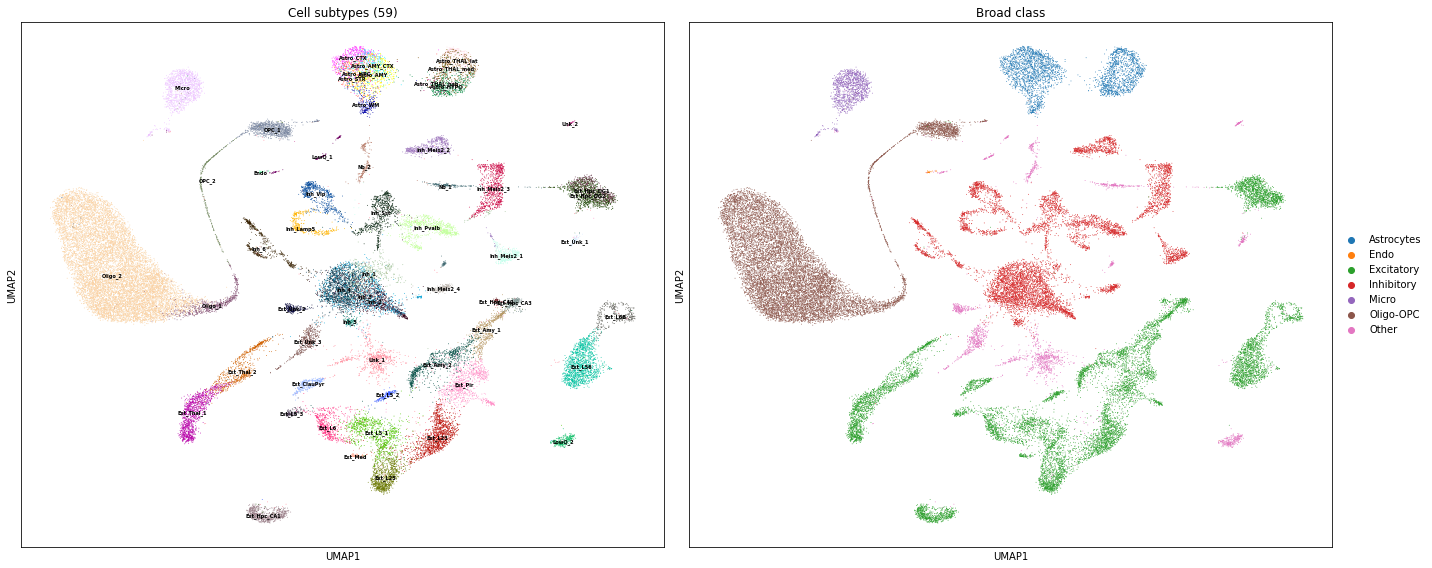

Figure 2b saved


In [5]:
import matplotlib.pyplot as plt

# Define broad class groupings matching the paper legend
broad_class_map = {
    "Astrocytes": [c for c in adata_snrna.obs["annotation_1"].unique() if "Astro" in c],
    "Excitatory": [c for c in adata_snrna.obs["annotation_1"].unique() if "Ext" in c],
    "Inhibitory": [c for c in adata_snrna.obs["annotation_1"].unique() if "Inh" in c],
    "Oligo-OPC":  [c for c in adata_snrna.obs["annotation_1"].unique() if "Oligo" in c or "OPC" in c],
    "Micro":      [c for c in adata_snrna.obs["annotation_1"].unique() if "Micro" in c],
    "Endo":       [c for c in adata_snrna.obs["annotation_1"].unique() if "Endo" in c],
    "Other":      [c for c in adata_snrna.obs["annotation_1"].unique() if "Unk" in c],
}

# Map each cell to its broad class
broad_map_flat = {}
for broad, subtypes in broad_class_map.items():
    for s in subtypes:
        broad_map_flat[s] = broad

adata_snrna.obs["broad_class"] = adata_snrna.obs["annotation_1"].map(broad_map_flat).fillna("Other")

# Figure 2b — left panel: fine subtypes, right panel: broad class
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: 59 fine-grained subtypes
sc.pl.umap(
    adata_snrna,
    color="annotation_1",
    legend_loc="on data",
    legend_fontsize=5,
    title="Cell subtypes (59)",
    ax=axes[0],
    show=False
)

# Right: broad class
sc.pl.umap(
    adata_snrna,
    color="broad_class",
    legend_loc="right margin",
    title="Broad class",
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.savefig("figure_2b.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2b saved")

In [6]:
# Load all 5 Visium sections:
import cell2location

visium_samples = [
    "ST8059048", "ST8059049", "ST8059050", "ST8059051", "ST8059052"
]

slides = {}
for sample in visium_samples:
    h5_path = os.path.join(visium_dir, f"{sample}_filtered_feature_bc_matrix.h5")
    spatial_path = os.path.join(visium_dir, f"{sample}_spatial")
    
    adata_vis = sc.read_visium(
        path=spatial_path,
        count_file=h5_path,
        load_images=True
    )
    adata_vis.var_names_make_unique()
    adata_vis.obs["sample"] = sample
    slides[sample] = adata_vis
    print(f"Loaded {sample}: {adata_vis.shape}")

# Concatenate all 5 sections
adata_vis = sc.concat(list(slides.values()), label="sample", keys=visium_samples)
adata_vis.obs["sample"] = adata_vis.obs["sample"].astype(str)
print(f"Combined Visium: {adata_vis.shape}")

Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/opt/conda/envs/cellpymc/lib/python3.7/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Loaded ST8059048: (2987, 31053)


Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Loaded ST8059049: (3499, 31053)


Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


...

Loaded ST8059051: (2409, 31053)


Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Loaded ST8059052: (2576, 31053)


Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


Combined Visium: (14968, 31053)


/opt/conda/envs/cellpymc/lib/python3.7/site-packages/anndata/_core/anndata.py:1192: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
... storing 'sample' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


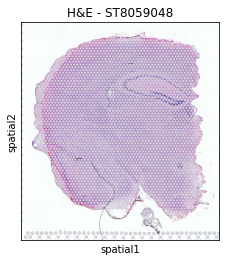

In [7]:
# Quick H&E plot (Figure 2c):
# Plot H&E for one representative section
sample_key = "ST8059048"
sc.pl.spatial(
    slides[sample_key],
    img_key="hires",
    color=None,
    title=f"H&E - {sample_key}",
    save="figure_2c_HE.png"
)

In [8]:
import cell2location
import numpy as np

# Use raw counts stored in layers["counts"]
adata_ref = adata_snrna.copy()
adata_ref.X = adata_ref.layers["counts"].copy()

# Manual gene filtering (replaces filter_genes)
# Keep genes expressed in >5% of cells
n_cells = adata_ref.shape[0]
gene_counts = (adata_ref.X > 0).sum(axis=0)
if hasattr(gene_counts, 'A1'):
    gene_counts = gene_counts.A1  # sparse matrix to array
pct_expressed = gene_counts / n_cells
selected = pct_expressed > 0.05

adata_ref = adata_ref[:, selected].copy()
print(f"Genes after filtering: {adata_ref.shape[1]}")

Genes after filtering: 10085


In [9]:
help(cell2location.run_regression)

Help on function run_regression in module cell2location.run_regression:

run_regression(sc_data, model_name=None, verbose=True, return_all=True, train_args={'covariate_col_names': [None], 'sample_name_col': None, 'tech_name_col': None, 'stratify_cv': None, 'n_epochs': 100, 'minibatch_size': 1024, 'learning_rate': 0.01, 'use_average_as_initial_value': True, 'use_cuda': True, 'train_proportion': 0.9, 'l2_weight': True, 'readable_var_name_col': None}, model_kwargs={}, posterior_args={}, export_args={'path': './results', 'save_model': True, 'run_name_suffix': ''})
    Run regression model: train, evaluate using cross-validation, choose training time that prevents over-fitting,
     evaluate the quality of experiment and technology correction, save, export results and save diagnostic plots
    
    Parameters
    ----------
    sc_data :
        anndata object with single cell / nucleus data
    model_name :
        model class object or None. If none, the default model is selected:
       

In [10]:
# old code block has error, doesn't run
results_regression = cell2location.run_regression(
    sc_data=adata_ref,
    train_args={
        'covariate_col_names': [None],
        'sample_name_col': 'sample',
        'tech_name_col': None,
        'n_epochs': 250,
        'minibatch_size': 2500,
        'learning_rate': 0.01,
        'use_average_as_initial_value': True,
        'use_cuda': False,
        'train_proportion': 0.9,
        'l2_weight': True,
        'use_raw': False,      # explicitly use adata_ref.X not adata_ref.raw
    },
    export_args={'path': './results_regression/', 'save_model': False}
)

# Extract reference signatures
inf_aver = results_regression['mod'].samples['post_sample_means']['per_cluster_mu_fg']
inf_aver = pd.DataFrame(
    inf_aver,
    index=adata_ref.var_names,
    columns=adata_ref.uns['mod_cell_types']
)
print(f"Reference signature matrix shape: {inf_aver.shape}")

KeyError: '[None] not in index'

In [11]:
# new code block - doesn't run
results_regression = cell2location.run_regression(
    sc_data=adata_ref,
    train_args={
        'covariate_col_names': [],          # ← was [None], must be []
        'sample_name_col': 'sample',
        'tech_name_col': None,
        'n_epochs': 250,
        'minibatch_size': 2500,
        'learning_rate': 0.01,
        'use_average_as_initial_value': True,
        'use_cuda': False,
        'train_proportion': 0.9,
        'l2_weight': True,
        'use_raw': False,
    },
    export_args={'path': './results_regression/', 'save_model': False}
)

# Extract reference signatures
inf_aver = results_regression['mod'].samples['post_sample_means']['per_cluster_mu_fg']
inf_aver = pd.DataFrame(
    inf_aver,
    index=adata_ref.var_names,
    columns=adata_ref.uns['mod_cell_types']
)
print(f"Reference signature matrix shape: {inf_aver.shape}")

### Creating model ### - time 0.05 min


ValueError: No objects to concatenate

In [ ]:
# new code block

# Add a dummy covariate column (constant value — no real effect on the model)
adata_ref.obs['dummy_covar'] = '1'

results_regression = cell2location.run_regression(
    sc_data=adata_ref,
    train_args={
        'covariate_col_names': ['dummy_covar'],  # ← dummy column to satisfy library
        'sample_name_col': 'sample',
        'tech_name_col': None,
        'n_epochs': 250,
        'minibatch_size': 2500,
        'learning_rate': 0.01,
        'use_average_as_initial_value': True,
        'use_cuda': False,
        'train_proportion': 0.9,
        'l2_weight': True,
        'use_raw': False,
    },
    export_args={'path': './results_regression/', 'save_model': False}
)

# Extract reference signatures
inf_aver = results_regression['mod'].samples['post_sample_means']['per_cluster_mu_fg']
inf_aver = pd.DataFrame(
    inf_aver,
    index=adata_ref.var_names,
    columns=adata_ref.uns['mod_cell_types']
)
print(f"Reference signature matrix shape: {inf_aver.shape}")

### Creating model ### - time 0.05 min
### Analysis name: RegressionGeneBackgroundCoverageTorch_7covariates_40532cells_10085genes
### Training model to determine n_epochs with CV ###


/opt/conda/envs/cellpymc/lib/python3.7/site-packages/torch/autograd/__init__.py:132: UserWarning: CUDA initialization: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx (Triggered internally at  /pytorch/c10/cuda/CUDAFunctions.cpp:100.)


In [12]:
print(results_regression['mod'].samples['post_sample_means'].keys())
print(results_regression.keys())
print(adata_ref.uns.keys())

NameError: name 'results_regression' is not defined

In [ ]:
adata_vis.layers["counts"] = adata_vis.X.copy()

intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()
print(f"Shared genes: {len(intersect)}")

In [ ]:
results_c2l = cell2location.run_cell2location(
    sc_ref=inf_aver,
    sp_data=adata_vis,
    train_args={
        'n_epochs': 20000,
        'minibatch_size': None,  # use full data
        'learning_rate': 0.001,
        'use_cuda': False,  # set True if GPU available
    },
    model_kwargs={
        'cell_number_prior': {
            'cells_per_spot': 8,        # N_cells_per_location from paper
            'factors_per_spot': 7,
            'combs_per_spot': 2.5
        },
        'cell_number_var': {
            'cells_per_spot_dtype': 'float32',
            'alpha_polynomial': 1,
            'alpha_mean': 200           # detection_alpha from paper
        }
    },
    export_args={'path': './results_c2l/', 'save_model': False}
)

adata_vis = results_c2l['sp_data']
print("Spatial mapping complete")
print(adata_vis.obs.columns.tolist())

In [ ]:
import matplotlib.pyplot as plt

sample_id = "ST8059048"
adata_plot = adata_vis[adata_vis.obs["sample"] == sample_id].copy()

# Check what abundance columns are available
abundance_cols = [col for col in adata_plot.obs.columns if col in inf_aver.columns]
print(f"Available cell type columns: {len(abundance_cols)}")

# Figure 2d — major regional subtypes
fig2d_celltypes = [ct for ct in ["Oligo_2", "Inh_Meis2_3", "Inh_4", "Ext_Thal_1", "Ext_L56"] 
                   if ct in adata_plot.obs.columns]
sc.pl.spatial(
    adata_plot,
    color=fig2d_celltypes,
    img_key="hires",
    size=1.3,
    ncols=3,
    vmin=0,
    vmax="p99",
    save="figure_2d.png"
)

# Figure 2e — sparse inhibitory neurons
fig2e_celltypes = [ct for ct in ["Inh_Sst", "Inh_Lamp5", "Inh_Vip"]
                   if ct in adata_plot.obs.columns]
sc.pl.spatial(
    adata_plot,
    color=fig2e_celltypes,
    img_key="hires",
    size=1.3,
    ncols=3,
    vmin=0,
    vmax="p99",
    save="figure_2e.png"
)

# Figure 2f — cortical excitatory layer subtypes
fig2f_celltypes = [ct for ct in ["Ext_L23", "Ext_L56", "Ext_L6B", "Ext_L25", "Ext_L5_2"]
                   if ct in adata_plot.obs.columns]
sc.pl.spatial(
    adata_plot,
    color=fig2f_celltypes,
    img_key="hires",
    size=1.3,
    ncols=3,
    vmin=0,
    vmax="p99",
    save="figure_2f.png"
)